In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import shap
import tensorflow as tf

In [3]:
file_path = r'C:\Users\sharif\Desktop\Final5.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""METHANOL"").F","STREAMS(""METHANOL"").T","STREAMS(""METHANOL"").P","STREAMS(""FV"").F","STREAMS(""FV"").T","STREAMS(""FV"").P","STREAMS(""FV"").Zmn(""1-BUT-01"")","STREAMS(""FV"").Zmn(""ISOBU-01"")","STREAMS(""P1"").F","STREAMS(""P1"").T",...,"BLOCKS(""RDCOLUMN"").Stage(4).T","BLOCKS(""RDCOLUMN"").Stage(5).T","BLOCKS(""RDCOLUMN"").Stage(6).T","BLOCKS(""RDCOLUMN"").Stage(7).T","BLOCKS(""RDCOLUMN"").Stage(8).T","BLOCKS(""RDCOLUMN"").Stage(9).T","BLOCKS(""RDCOLUMN"").Stage(10).T","BLOCKS(""RDCOLUMN"").Stage(11).T","STREAMS(""P1"").Zmn(""1-BUT-01"")","STREAMS(""P2"").Zmn(""METHY-01"")"
0,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
1,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
2,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
3,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3314,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974
4,712.082,46.85,1.01325,1965.0,178.574,12.1592,0.64,0.36,1340.14,76.3313,...,105.113,115.106,120.103,122.286,123.236,123.67,123.896,128.634,0.936555,0.965974


In [4]:
data = df.values
X_raw = data[:, :-2]  
Y_raw = data[:, -2:] 

In [5]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
X_scaled = x_scaler.fit_transform(X_raw)
Y_scaled = y_scaler.fit_transform(Y_raw)

In [6]:
def create_sequences(X, Y, time_steps=10):
    Xs, Ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        Ys.append(Y[i + time_steps])
    return np.array(Xs), np.array(Ys)

In [7]:
time_steps = 10
X_seq, Y_seq = create_sequences(X_scaled, Y_scaled, time_steps)

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, Y_seq, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [9]:
inputs = Input(shape=(time_steps, X_seq.shape[2]))
lstm_out = LSTM(128, return_sequences=True)(inputs)
attention = Attention()([lstm_out, lstm_out])
concat = Concatenate()([lstm_out, attention])
lstm_out2 = LSTM(64)(concat)
dense = Dense(64, activation='relu')(lstm_out2)
output = Dense(2)(dense)

model = Model(inputs, output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 36)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 10, 128)   │     84,480 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 10, 128)   │          0 │ lstm[0][0],       │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 10, 256)   │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     82,176 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        130 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 170,946 (667.76 KB)

 Trainable params: 170,946 (667.76 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=55, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=200,
                    batch_size=64,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0392 - mae: 0.0982 - val_loss: 0.0019 - val_mae: 0.0278
Epoch 2/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0013 - mae: 0.0187 - val_loss: 0.0127 - val_mae: 0.1045
Epoch 3/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0033 - mae: 0.0322 - val_loss: 5.7279e-04 - val_mae: 0.0107
Epoch 4/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 5.5373e-04 - mae: 0.0116 - val_loss: 3.8012e-04 - val_mae: 0.0080
Epoch 5/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 2.9398e-04 - mae: 0.0082 - val_loss: 4.7220e-04 - val_mae: 0.0109
Epoch 6/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 2.6908e-04 - mae: 0.0082 - val_loss: 3.2937e-04 - val_mae: 0.0094
Epoch 7/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 2.7815e-04 - mae: 0.0091 - val_loss: 5.7386e-04 - val_mae: 0.0170
Epoch 8/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 2.9547e-04 - mae: 0.0094 - val_loss: 5.6027e-04 - val_mae: 0.0

In [11]:
y_pred = model.predict(X_test)
y_test_inv = y_scaler.inverse_transform(y_test)
y_pred_inv = y_scaler.inverse_transform(y_pred)

for i in range(2):
    print(f"Target {i+1} - R2: {r2_score(y_test_inv[:, i], y_pred_inv[:, i]):.4f}, MSE: {mean_squared_error(y_test_inv[:, i], y_pred_inv[:, i]):.4f}, MAE: {mean_absolute_error(y_test_inv[:, i], y_pred_inv[:, i]):.4f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Target 1 - R2: 0.9905, MSE: 0.0000, MAE: 0.0003
Target 2 - R2: 0.9978, MSE: 0.0000, MAE: 0.0006


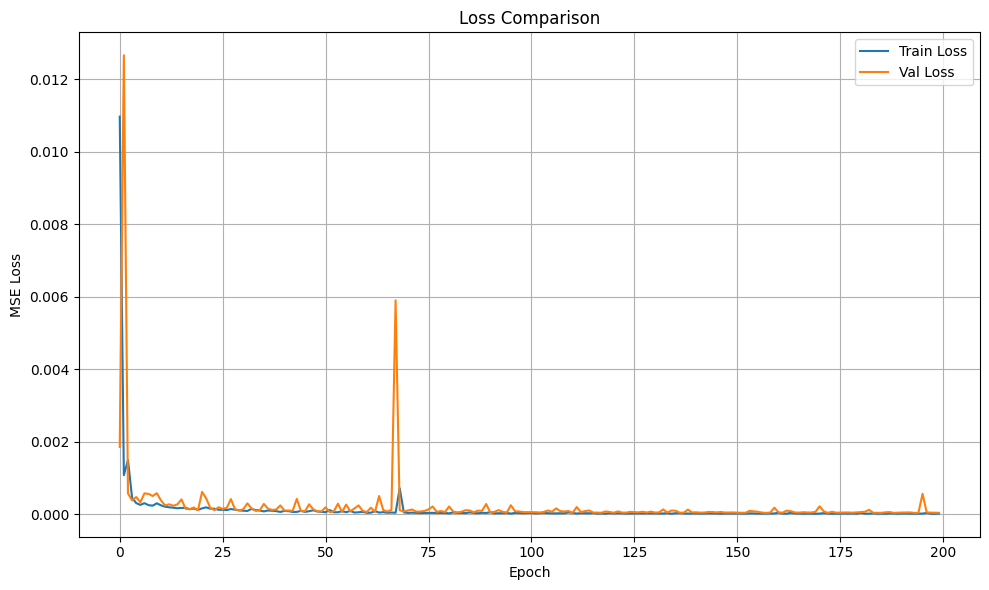

In [12]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

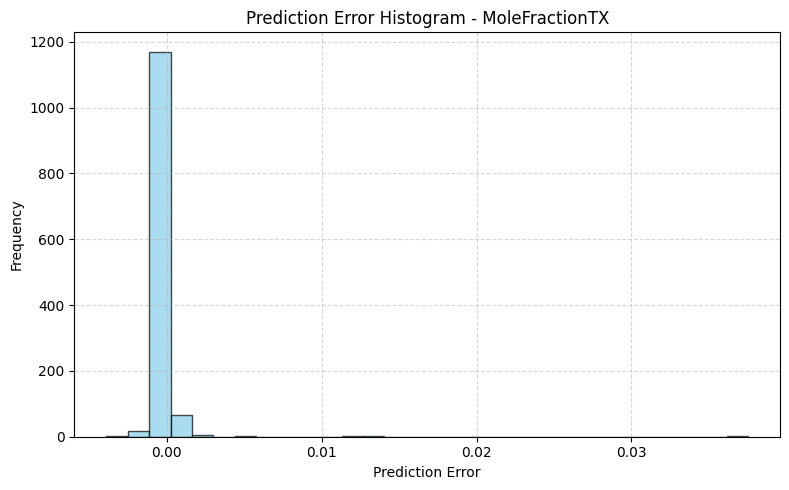

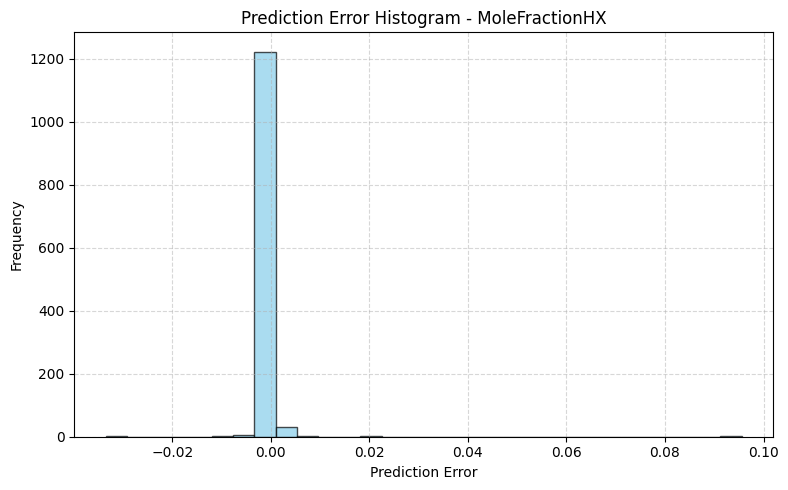

In [13]:
errors = y_test_inv - y_pred_inv
labels = ['MoleFractionTX', 'MoleFractionHX']

for i in range(2):
    plt.figure(figsize=(8, 5))
    plt.hist(errors[:, i], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Prediction Error Histogram - {labels[i]}')
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [14]:
df_results = pd.DataFrame({
    'Actual TX': y_test_inv[:, 0],
    'Predicted TX': y_pred_inv[:, 0],
    'Actual HX': y_test_inv[:, 1],
    'Predicted HX': y_pred_inv[:, 1]
})

print(df_results.head(20))

    Actual TX  Predicted TX  Actual HX  Predicted HX
0    0.938403      0.938509   0.959167      0.958933
1    0.938403      0.938509   0.959169      0.958932
2    0.936371      0.936331   0.965906      0.965820
3    0.938403      0.938509   0.959166      0.958933
4    0.938403      0.938509   0.959169      0.958932
5    0.937808      0.937954   0.958299      0.957984
6    0.937129      0.937017   0.965848      0.965723
7    0.902417      0.904294   0.938026      0.939646
8    0.938403      0.938509   0.959169      0.958932
9    0.938403      0.938509   0.959166      0.958933
10   0.938930      0.939011   0.960166      0.959784
11   0.936561      0.936416   0.965977      0.965562
12   0.930160      0.930278   0.963375      0.963215
13   0.938403      0.938509   0.959167      0.958932
14   0.936513      0.936460   0.965962      0.965862
15   0.925699      0.926000   0.960936      0.961444
16   0.938478      0.938572   0.959199      0.958963
17   0.936626      0.936476   0.966004      0.

In [15]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [16]:
tolerances = [0.005, 0.002, 0.001]

# دو خروجی داریم: TX (ستون 0) و HX (ستون 1)
tx_true = y_test_inv[:, 0]
tx_pred = y_pred_inv[:, 0]
hx_true = y_test_inv[:, 1]
hx_pred = y_pred_inv[:, 1]

tx_results = []
hx_results = []

In [17]:
for tol in tolerances:
    tx_acc = percentage_within_tolerance(tx_true, tx_pred, tolerance=tol)
    hx_acc = percentage_within_tolerance(hx_true, hx_pred, tolerance=tol)
    tx_results.append(tx_acc)
    hx_results.append(hx_acc)
    print(f"TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {tx_acc:.2f}%")
    print(f"HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±{tol}: {hx_acc:.2f}%")
    print('-'*50)

TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 99.76%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.005: 99.53%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 99.13%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.002: 95.73%
--------------------------------------------------
TX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 97.00%
HX - درصد پیش‌بینی‌ها با اختلاف ≤ ±0.001: 92.02%
--------------------------------------------------


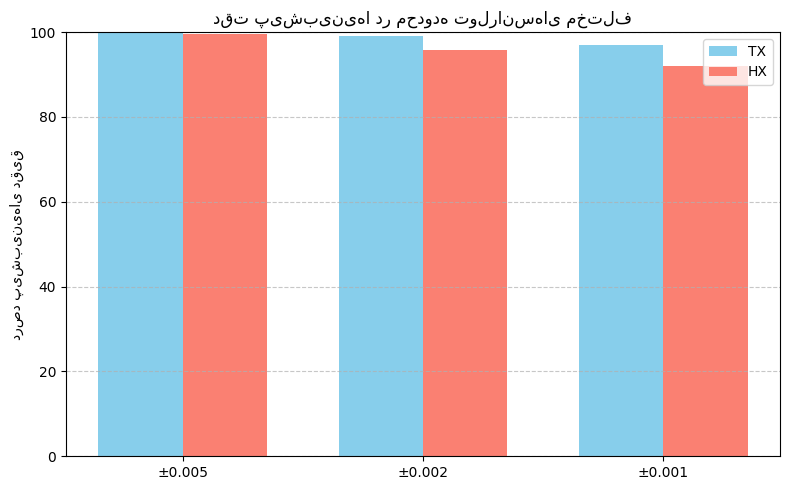

In [18]:
import matplotlib.pyplot as plt
x_labels = [f"±{tol}" for tol in tolerances]
x = np.arange(len(tolerances))

plt.figure(figsize=(8, 5))
bar_width = 0.35

plt.bar(x - bar_width/2, tx_results, width=bar_width, label='TX', color='skyblue')
plt.bar(x + bar_width/2, hx_results, width=bar_width, label='HX', color='salmon')

plt.xticks(x, x_labels)
plt.ylim(0, 100)
plt.ylabel("درصد پیش‌بینی‌های دقیق")
plt.title("دقت پیش‌بینی‌ها در محدوده تولرانس‌های مختلف")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
results = pd.DataFrame({
    'Actual MoleFractionTX': y_test_inv[:, 0],
    'Predicted MoleFractionTX': y_pred_inv[:, 0],
    'Actual MoleFractionHX': y_test_inv[:, 1],
    'Predicted MoleFractionHX': y_pred_inv[:, 1]
})

print(results.head())

   Actual MoleFractionTX  Predicted MoleFractionTX  Actual MoleFractionHX  \
0               0.938403                  0.938509               0.959167   
1               0.938403                  0.938509               0.959169   
2               0.936371                  0.936331               0.965906   
3               0.938403                  0.938509               0.959166   
4               0.938403                  0.938509               0.959169   

   Predicted MoleFractionHX  
0                  0.958933  
1                  0.958932  
2                  0.965820  
3                  0.958933  
4                  0.958932  


Total number of samples: 1265
Plotting first 5000 samples.


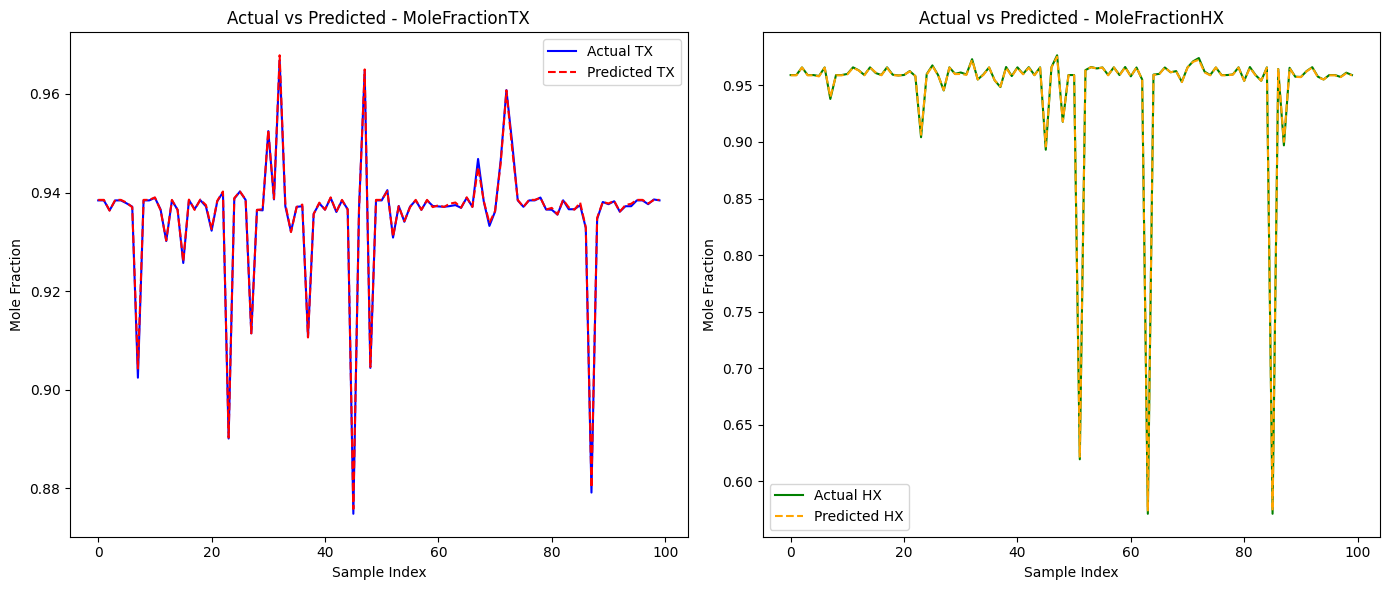

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# بررسی تعداد کل داده‌ها
num_samples = len(results)
print(f"Total number of samples: {num_samples}")

# اگر داده‌ها بیشتر از 5000 بودند، فقط 5000 تای اول را انتخاب کن
if num_samples >= 100:
    subset = results.iloc[:100]
    print("Plotting first 5000 samples.")
else:
    subset = results
    print("Plotting all available samples.")

# رسم نمودار
plt.figure(figsize=(14, 6))

# MoleFractionTX
plt.subplot(1, 2, 1)
plt.plot(subset['Actual MoleFractionTX'].values, label='Actual TX', color='blue')
plt.plot(subset['Predicted MoleFractionTX'].values, label='Predicted TX', color='red', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionTX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

# MoleFractionHX
plt.subplot(1, 2, 2)
plt.plot(subset['Actual MoleFractionHX'].values, label='Actual HX', color='green')
plt.plot(subset['Predicted MoleFractionHX'].values, label='Predicted HX', color='orange', linestyle='--')
plt.title('Actual vs Predicted - MoleFractionHX')
plt.xlabel('Sample Index')
plt.ylabel('Mole Fraction')
plt.legend()

plt.tight_layout()
plt.show()